# DSL Examples — engineering math in plain notation

A small gallery of one-cell examples showing what the toolkit makes possible.
Each example is self-contained: open a fresh Jupyter kernel, run the import
cell once, then drop into any example below.

## Setup (run once)

In [1]:
from utils.Engineer import *

---
## Electrical engineering

### Parallel resistors (`‖`)

The `‖` operator does what every electrical engineer types informally on
paper — combine resistors in parallel.  No `1/(1/R1 + 1/R2)` boilerplate.

In [2]:
R_a := 4.7 kΩ
R_b := 10. kΩ
R_total := R_a ‖ R_b
pp('R_total=',R_total)

<IPython.core.display.Math object>

### Voltage divider

Subscripts on identifiers, dot multiplication, automatic prefix scaling on
the result.  The `·` is just a more readable `*`.

In [3]:
V_in := 12.0 V
R_top := 4.7 kΩ
R_bot := 10. kΩ
V_out := V_in · R_bot/(R_top + R_bot)
V_out

8.2 V

### Three resistors in parallel

Chained `‖` is left-associative — same as the math.

In [4]:
R_1 := 100.0 Ω
R_2 := 220.0 Ω
R_3 := 470.0 Ω
R_eq := R_1 ‖ R_2 ‖ R_3
pv(R_eq)

<IPython.core.display.Math object>

### RC time constant

Units of `Ω · F` automatically simplify to seconds (auto-prefixed to ms
because that's the natural scale).

In [5]:
R_load := 10. kΩ
C_filter := 100. nF
τ := R_load · C_filter
pv(τ)

<IPython.core.display.Math object>

### Energy stored in a capacitor

Fractions written as `½` (vulgar-fraction Unicode) read as `1/2`.
The `²` is a postfix square — `V_c²` becomes `V_c**2`.

In [6]:
C_cap := 470. μF
V_c := 12. V
E_stored := ½ · C_cap · V_c²
pv(E_stored)

<IPython.core.display.Math object>

### Frequency from period

Just division — units carry through.  `1/ms` becomes `kHz` automatically.

In [7]:
T_period := 25. ms
freq := 1/T_period
pv(freq)

<IPython.core.display.Math object>

### Worst-case analysis with tolerance ranges

`±` builds an interval, and intervals propagate through all arithmetic. Model each component family's total tolerance — initial, temperature drift, end-of-life — as a dimensionless multiplier, apply it to the nominal values, and the worst-case output falls out of the ordinary circuit math. A bare `pv()` prints every variable defined so far.

In [8]:
EOL := 0.04%                  # end-of-life drift
ΔT := 60 ΔC                   # ambient rise above 25 ℃
std, prec, ref := 1 ± (1% + 100 ppm/℃ · ΔT + EOL), 1 ± (0.1% + 25 ppm/℃ · ΔT + EOL), 1 ± (1.5% + EOL)

In [9]:
R1, R2, R3, R4, Vr := 51.1 Ω std, 28.7 kΩ prec, 10.0 kΩ prec, 2.2 MΩ std, 0.85 V ref

In [10]:
Rt, Rb := R1 + R2, R3 ‖ R4
Vo := Vr · (Rt / Rb + 1)
pv(Vo)

<IPython.core.display.Math object>

In [11]:
pv()                          # every variable so far, with its interval

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## Mechanical engineering

### Pythagoras with mixed-prefix lengths

`√` works directly on unit-bearing quantities — the toolkit wraps sympy's
`sqrt` with a fallback to `**0.5`, and forallpeople's Physical handles
the latter natively (halving the dimension: m² → m).

In [12]:
leg_a := 30. cm
leg_b := 40. cm
hyp := √(leg_a² + leg_b²)
pv(hyp)

<IPython.core.display.Math object>

### Weight from mass

`g_0` is the standard gravitational acceleration (9.80665 m·s⁻²) —
no need to type or remember the constant.

In [13]:
mass := 5.0 kg
F_grav := mass · g_0
pv(F_grav)

<IPython.core.display.Math object>

### Kinetic energy from km/h

Forallpeople accepts `km/hour` directly.  The square `speed²` produces
`(km/hour)²` which combines with kg to give energy — auto-displayed in kJ.

In [14]:
car_mass := 1500 kg
speed := 90. km/hour
K_E := ½ · car_mass · speed²
pv(K_E)

<IPython.core.display.Math object>

### Drag-race acceleration

Velocity ÷ time = acceleration; units fall out naturally.

In [15]:
v_final := (100. kph) ▸ kph#something wrong here
t_accel := 4.2 s
a := v_final / t_accel
pv(v_final,t_accel,a)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Thermal expansion of a steel beam

`Δ` (capital delta) is a valid identifier prefix.  Coefficient of linear
expansion `α = 12e-6 /K` for steel.  Over 25 K, a 10 m beam grows 3 mm.

In [16]:
L_init := 10.0 m
α := 12e-6 / K
ΔT := 25. K
ΔL := L_init · α · ΔT
pv(ΔL)

<IPython.core.display.Math object>

### Temperature: absolute vs. delta

Temperature units are offset-correct. `°C`/`°F`/`°R` are points on
a scale: `22 °C` is stored as `295.15 K` and displays as `22 °C`.
`ΔK`/`ΔC`/`ΔF` are temperature *differences* with no offset — use
them for coefficients and changes. Adding a difference to an
absolute temperature does what you want; the result comes back in
SI, and `▸ degC` / `▸ degF` re-express it on another scale.

In [17]:
T_room := 22 °C               # absolute — offset applied
warmer := T_room + 3 ΔC       # add a difference
pv(T_room, warmer, warmer ▸ degC)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The ``to_*`` helpers convert *bare numbers* between scales, for
when you are working outside the unit system:

In [18]:
room_C := 22.0
room_K := to_kelvin(room_C)           # 295.15
room_F := to_fahrenheit(room_C)       # 71.6
pv(room_C, room_K, room_F)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## Fluid mechanics

### Reynolds number (dimensionless)

When dimensions cancel, the result is a plain number — the toolkit doesn't
add "dimensionless" stamping.

In [19]:
ρ_water := 1000. kg/m³
v_pipe := 1.5 m/s
diameter := 50. mm
μ_water := 1.0e-3 Pa·s
Re := ρ_water · v_pipe · diameter / μ_water
pv(Re)

<IPython.core.display.Math object>

---
## Control flow

### Inequality for-loop

Loop bounds in math notation — `for 1 ≤ k ≤ 5` is `range(1, 6)`.  Both
bounds inclusive matches the math convention; use `<` for exclusive.

In [20]:
squares := []
for 1 ≤ k ≤ 5:
    squares.append(k²)
pv(squares)

<IPython.core.display.Math object>

### Inequality for, exclusive upper

`<` and `≤` mix freely; the rewriter handles all eight combinations of
strict/non-strict and ascending/descending.

In [21]:
odd := []
for 1 ≤ k < 10:
    if k % 2 = 1:
        odd.append(k)
pv(odd)

<IPython.core.display.Math object>

---
## Set operations

### Intersection (`∩`) and union (`∪`)

Curly braces make a set; `∩` and `∪` are the obvious operators.

In [22]:
squares := {1, 4, 9, 16, 25}
primes := {2, 3, 5, 7, 11, 13}
both := squares ∩ primes
either := squares ∪ primes
pv(both, either)

both = ∅
either = {1, 2, 3, 4, 5, 7, 9, 11, 13, 16, 25}


### The full glyph set

`∖` is set difference, `△` symmetric difference, `∈`/`∉` membership, `⊆` subset — and `←` assigns just like `:=`. A bare `=` at statement level is equality (inside a call it stays a keyword argument, so compare on its own line).

In [23]:
odds ← {1, 3, 5, 7}
primes ← {2, 3, 5, 7}
pp(odds ∖ primes, odds ∪ primes, odds ∩ primes, odds △ primes)
pp(3 ∈ odds, 9 ∉ primes, {3, 5} ⊆ odds)
odds = primes                 # bare = is equality → False

{1} {1, 2, 3, 5, 7} {3, 5, 7} {1, 2}
True True True


False

---
## Number forms

### Hexadecimal via subscript

`fed₁₆` reads as "FED in base 16."  Other bases work the same way:
`11111111₂` for binary, `777₈` for octal.

In [24]:
hex_color := fed₁₆
binary_val := 11111111₂
pv(hex_color, binary_val)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Percent and per-mille

`%` divides by 100; `‰` (per-mille) divides by 1000.

In [25]:
tax := 25%
fine_concentration := 5‰
pv(tax, fine_concentration)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## Plotting

### I-V characteristic from measurements

`plot()` reads units off the data and labels axes accordingly.
The `("data", "o")` tuple labels the series and uses scatter markers.

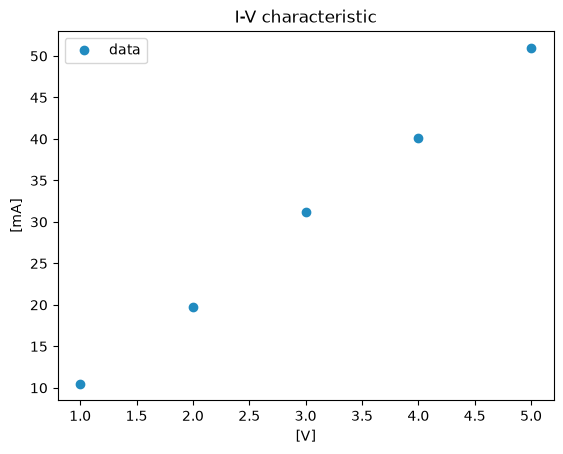

In [26]:
voltage := [1.0, 2.0, 3.0, 4.0, 5.0] V
current := [10.5, 19.8, 31.2, 40.1, 51.0] mA
plot(voltage, current, ("data", "o"), title="I-V characteristic")

### RC discharge — symbolic

A symbolic expression in `t` swept over a range.  No `lambdify` boilerplate.

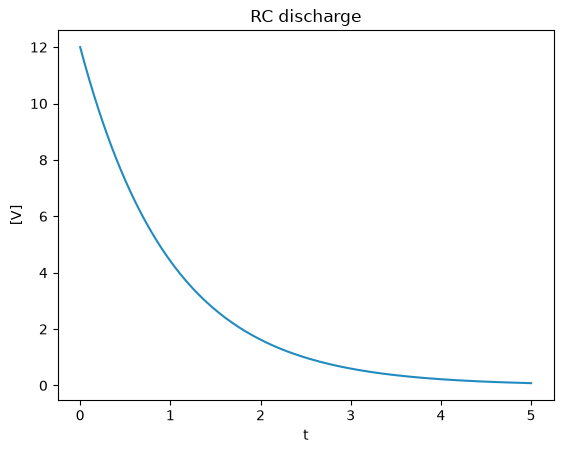

In [27]:
symbols: t
V_0 := 12. V
τ := 1.0 ms
expr := V_0 · exp(-t/τ)
plot(expr, t, (0, 5), title="RC discharge")

### Damped oscillation

The DSL's `²` postfix-square and `↑` power operator (when written `e↑`)
both feed into a symbolic expression that gets numerically swept.

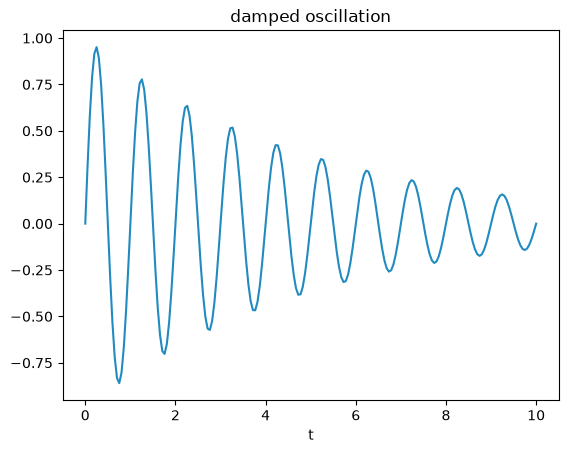

In [28]:
symbols: t
expr := exp(-t/5) · sin(2 · π · t)
plot(expr, t, (0, 10), title="damped oscillation")

### Gaussian fit — data + symbolic model in ONE call

The headline pattern: scatter measurements + symbolic fit curve overlaid
in a single `plot()` call.  Each series carries its own
`(label, style)` annotation for legend + per-series styling.

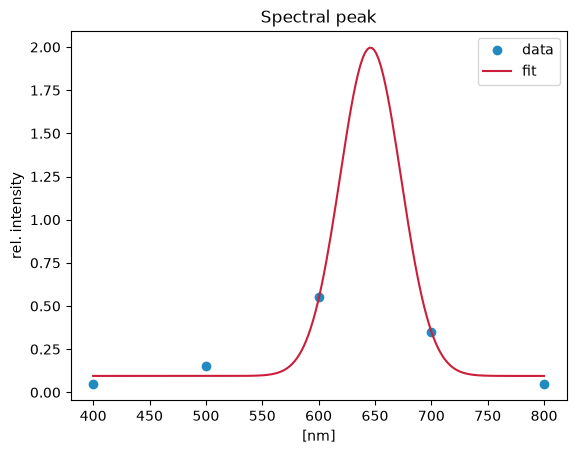

In [29]:
symbols: x
Io := 2 · 0.951
λ := 646 nm
σ := 27 nm
offset := 0.095
x_data := [400, 500, 600, 700, 800] nm
y_data := [0.05, 0.15, 0.55, 0.35, 0.05]▸ "rel. intensity"
fit_expr := Io · e↑(- (x - λ)² / (2 · σ²)) + offset
plot(x_data, y_data, ("data", "o"),
     fit_expr, x, (400, 800), ("fit", "-"),
     title="Spectral peak")

---
## Things to know

- **`▸` is for display only.**  `90 km/hour ▸ m/s` *shows* m/s but isn't a
  usable Physical for further math.  For actual unit work, let
  forallpeople auto-prefix.
- **Single-letter unit names are protected.**  `R`, `C`, `F`, `T`, `V`,
  `c`, `A` etc. can't be used as variable names — pick longer names
  (`R_load`, `cap`, `V_in`).
- **Subscript-digit identifiers become indexing.**  `R₁`, `R₂` rewrite to
  `R[1]`, `R[2]`, requiring `R` to exist as a list.  Use `R_1`, `R_2` if
  you want plain variables.
- **Tight value-unit binding.**  `12 V / 3 A` parses as `(12 V)/(3 A) = 4 Ω`,
  not `((12·V/3)·A) = 12 W` — units bind tighter than `*` and `/`.

## More notation

The examples below show further notation — Roman-numeral literals, superscript-decimal exponents, string and symbol ranges, radix display over arrays, and matrix algebra on `[[…]]` literals.

### Roman numerals — read in, display out

The `ᵣₒₘₑ` subscript parses a Roman-numeral string **into** an integer; `▸ roman` is the inverse, displaying an integer **as** Roman numerals. Between them the value is a plain `int`. Additive forms like `IIII` (the clock-face four) are accepted alongside the subtractive `IV`.

In [30]:
year := "MCMXCIV"ᵣₒₘₑ        # 1994 — reads the Roman string
clock_four := "IIII"ᵣₒₘₑ     # 4 — additive form accepted
pp(year, clock_four, 6, year ▸ roman)

<IPython.core.display.Math object>

### Superscript decimal exponent

A non-integer power can be written as a superscript using the raised dot `˙` (U+02D9) as the decimal point: `k⁰˙⁵⁵` means `k**0.55`. The trailing zeros assert precision, just like any other literal.

In [31]:
k := 10000
k⁰˙⁵⁵                        # k**0.55 — three spellings: k↑0.55, k**0.55, k⁰˙⁵⁵

160

### String and label ranges

The `..` range operator works on string endpoints — digits, single letters (incl. Greek), or a prefix with a numeric tail. Zero-padding is preserved when the start is padded. Ranges and single items mix freely inside one list.

In [32]:
['1'..'5']                   # ['1','2','3','4','5']
['A'..'E']                   # ['A','B','C','D','E']
['R099'..'R102']             # ['R099','R100','R101','R102'] — pad kept
pp(['C8'..'C13', 'R20', 'a'..'f'])   # mixed: ranges + singletons
pp(27°C)
pp(12 m/s)

['C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'R20', 'a', 'b', 'c', 'd', 'e', 'f']


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Ranges also expand in **symbol declarations** — `x..z` and `R1..R4` become the full sequence of sympy symbols:

In [33]:
symbols: x..z, R1..R4
pp("symbols:", x, y, z, R1, R2, R3, R4)

<IPython.core.display.Math object>

### Radix display over arrays

A `▸ hex` / `▸ bin` display tag broadcasts over a list, formatting each element. `▸` is a pure display preference, so re-tagging is idempotent and `▸ dec` reverts — the underlying value never changes.

In [34]:
pp([10, 20, 255] ▸ hex, (255 ▸ hex) + 1, 255 ▸ hex ▸ dec,1,2,3,4) 

<IPython.core.display.Math object>

### Matrices — `[[…]]` is a real matrix

A list-of-lists literal is a matrix with full linear algebra: product, inverse, determinant, eigenvalues. The `ᵀ` superscript transposes, and the `͵` separator (U+0375) gives 2-D indexing `M₀͵₁`. Symbolic entries work identically.

In [35]:
M := [[1,2],[3,4]]
pp("M_det=",M.det(), ", M_inv=",M.inv(), ", M⁷=",M·M·M·M·M·M·M)

<IPython.core.display.Math object>

In [36]:
M := [[1,2,3],[4,5,6]]
pp(M₀͵₁, Mᵀ)                     # row 0, col 1 = 2 (0-indexed);  transpose

<IPython.core.display.Math object>

In [37]:
symbols: alpha, beta, gamma, delta
Jac := [[alpha, beta],[gamma, delta]]
Jac.det()                    # alpha*delta - beta*gamma

alpha*delta - beta*gamma

With `pp`, a matrix typesets as a bracketed matrix — and a radix tag carries into the display:

In [38]:
M := [[1,2,3],[4,5,6],[10, 11, 12]]
pp(M ▸ hex)                  # a hex-formatted matrix

<IPython.core.display.Math object>

### Matrices are 0-indexed

A DSL matrix is 0-indexed, like everything else in Python: the first row and column are **0**. Subscript access `M₀͵₁` and assignment are 0-based, negative indices count from the end, and out-of-range indices raise a clear error — the same convention as plain Python lists, so one numbering rule holds everywhere.

In [39]:
M := [[10,20,30], [40,50,60]]
pp(M₀͵₀, M₁͵₂)                    # row 0 col 0 = 10;  row 1 col 2 = 60

<IPython.core.display.Math object>

In [40]:
M := [[1,2],[3,4]]
M₀͵₁ := 99                    # 0-based assignment
pv(M)                            # [[1,99],[3,4]]

<IPython.core.display.Math object>

### Matrices with units and symbols

A matrix literal takes a unit like any other value, and symbolic entries from `symbols:` work identically — here an outer product built from a column and a row.

In [41]:
P_grid := [[1, 2, 3], [4, 5, 6]] mW
pp(P_grid)

<IPython.core.display.Math object>

In [42]:
symbols: α..δ
Mrow := [[sin(α), β³, γ, δ]]
Mcol := [[sin(α)], [β³], [γ], [δ]]
pp(Mcol × Mrow)

<IPython.core.display.Math object>